<a href="https://colab.research.google.com/github/MohdFuzailHaider/flyrank/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## Loading dataset

In [27]:
from google.colab import userdata
from huggingface_hub import hf_hub_download

import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

HF_TOKEN = userdata.get("HF_TOKEN")

def load_month(month):
    path = hf_hub_download(
        repo_id="FlyRank/internship-warehouse",
        repo_type="dataset",
        filename=f"fact_content_daily_performance/month={month}/data_0.parquet",
        token=HF_TOKEN,
    )

    return pd.read_parquet(path)

In [28]:
mar = load_month("2026-03")

mar["report_date"] = pd.to_datetime(mar["report_date"])

print("Dataset shape:", mar.shape)
print(
    "Date range:",
    mar["report_date"].min(),
    "to",
    mar["report_date"].max()
)

Dataset shape: (9841378, 30)
Date range: 2026-03-01 00:00:00 to 2026-03-31 00:00:00


In [29]:
early = mar[
    (mar["report_date"] >= "2026-03-01") &
    (mar["report_date"] <= "2026-03-15")
].copy()

late = mar[
    (mar["report_date"] >= "2026-03-16") &
    (mar["report_date"] <= "2026-03-31")
].copy()

print("Observation period rows:", early.shape)
print("Outcome period rows:", late.shape)

Observation period rows: (4642255, 30)
Outcome period rows: (5199123, 30)


In [30]:
early_features = (
    early.groupby(
        ["client_hash_id", "content_hash_id"],
        as_index=False
    )
    .agg(
        impressions=("gsc_impressions", "sum"),
        clicks=("gsc_clicks", "sum"),
        avg_position=("gsc_avg_position", "mean"),
        pageviews=("ga4_pageviews", "sum"),
        sessions=("ga4_sessions", "sum"),
        users=("ga4_users", "sum"),
        engaged_sessions=("ga4_engaged_sessions", "sum"),
        engagement_sec=("ga4_total_engagement_sec", "sum"),
        organic_sessions=("sessions_organic", "sum"),
        scroll_events=("scroll_events", "sum"),
    )
)

In [31]:
late_features = (
    late.groupby(
        ["client_hash_id", "content_hash_id"],
        as_index=False
    )
    .agg(
        late_impressions=("gsc_impressions", "sum")
    )
)

In [32]:
model_df = early_features.merge(
    late_features,
    on=["client_hash_id", "content_hash_id"],
    how="left"
)

model_df["late_impressions"] = (
    model_df["late_impressions"].fillna(0)
)

model_df["early_daily_impressions"] = (
    model_df["impressions"] / 15
)

model_df["late_daily_impressions"] = (
    model_df["late_impressions"] / 16
)

model_df["is_declining"] = (
    (model_df["impressions"] > 0) &
    (
        model_df["late_daily_impressions"]
        < model_df["early_daily_impressions"]
    )
).astype(int)

print(model_df["is_declining"].value_counts())

is_declining
0    244254
1     75505
Name: count, dtype: int64


In [33]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

feature_cols = [
    "impressions",
    "clicks",
    "avg_position",
    "pageviews",
    "sessions",
    "users",
    "engaged_sessions",
    "engagement_sec",
    "organic_sessions",
    "scroll_events"
]

X = model_df[feature_cols]
y = model_df["is_declining"]

groups = model_df["client_hash_id"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

print(
    "Client overlap:",
    len(
        set(model_df.iloc[train_idx]["client_hash_id"])
        &
        set(model_df.iloc[test_idx]["client_hash_id"])
    )
)

Training rows: 265352
Test rows: 54407
Client overlap: 0


In [34]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [35]:
model_df["decline_probability"] = (
    rf_model.predict_proba(X)[:, 1]
)

model_df[[
    "content_hash_id",
    "decline_probability",
    "is_declining"
]].head()

,content_hash_id,decline_probability,is_declining
0,content_004e9c4c32e88631,8.364342e-07,0
1,content_0236ef736698e17c,8.364342e-07,0
2,content_025f6cfd3c298870,8.364342e-07,0
3,content_0263d5f9b7a2ecd4,8.364342e-07,0
4,content_02752c6c1c60161f,8.364342e-07,0


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

This prototype queue uses the model's estimated decline probability to rank content items for review. The ranking is intended as a directional decision-support signal rather than an automatic instruction to refresh or modify content.

Reason codes are generated from observed early-period feature patterns so that each recommendation can be reviewed by a human.

In [36]:
action_queue = model_df[
    [
        "client_hash_id",
        "content_hash_id",
        "decline_probability",
        "impressions",
        "clicks",
        "avg_position",
        "pageviews",
        "sessions",
        "engaged_sessions",
        "engagement_sec",
        "organic_sessions",
        "scroll_events"
    ]
].copy()

action_queue = action_queue.sort_values(
    "decline_probability",
    ascending=False
).reset_index(drop=True)

action_queue["priority_rank"] = action_queue.index + 1

action_queue.head(10)

,client_hash_id,content_hash_id,decline_probability,impressions,clicks,avg_position,pageviews,sessions,engaged_sessions,engagement_sec,organic_sessions,scroll_events,priority_rank
0,client_23a62021009f63c4,content_b584a8e78c254262,0.968244,16091,18,39.991381,86.0,78.0,3.0,152.0,28.0,11.0,1
1,client_23a62021009f63c4,content_436b5dc1edc1dd07,0.968128,17902,21,33.882071,46.0,35.0,3.0,98.0,27.0,4.0,2
2,client_23a62021009f63c4,content_7f59a2df31853855,0.965234,1684,0,33.029432,170.0,172.0,0.0,49.0,0.0,19.0,3
3,client_23a62021009f63c4,content_4704e13e0c70d8e8,0.964001,24759,25,38.649502,87.0,78.0,4.0,123.0,33.0,11.0,4
4,client_23a62021009f63c4,content_8bf3c4067c514f3c,0.963477,1246,0,30.475711,184.0,183.0,0.0,65.0,0.0,28.0,5
5,client_23a62021009f63c4,content_b196712c3dfd4f85,0.962320,4975,0,49.788772,184.0,189.0,0.0,70.0,0.0,24.0,6
6,client_23a62021009f63c4,content_a1216295ab0c5b21,0.960721,18139,11,36.055048,47.0,42.0,1.0,64.0,16.0,6.0,7
7,client_23a62021009f63c4,content_582a32591b0aabb9,0.959601,2708,0,37.568633,160.0,160.0,0.0,69.0,0.0,27.0,8
8,client_23a62021009f63c4,content_13f5b24061768509,0.958246,20267,25,32.649680,85.0,72.0,7.0,779.0,56.0,13.0,9
9,client_23a62021009f63c4,content_778c321ddc87ecaa,0.956202,893,0,45.956021,157.0,155.0,0.0,56.0,0.0,19.0,10


In [37]:
n = len(action_queue)

high_cutoff = int(n * 0.10)
medium_cutoff = int(n * 0.30)

def assign_priority(rank):
    if rank <= high_cutoff:
        return "High"
    elif rank <= medium_cutoff:
        return "Medium"
    else:
        return "Low"

action_queue["priority"] = action_queue[
    "priority_rank"
].apply(assign_priority)

action_queue["priority"].value_counts()

,count
priority,
Low,223832
Medium,63952
High,31975


In [38]:
def assign_action(priority):
    if priority == "High":
        return "Priority human review"
    elif priority == "Medium":
        return "Review when capacity allows"
    else:
        return "Monitor"

action_queue["recommended_action"] = action_queue["priority"].apply(
    assign_action
)

action_queue[
    ["priority_rank", "decline_probability", "priority", "recommended_action"]
].head(10)

,priority_rank,decline_probability,priority,recommended_action
0,1,0.968244,High,Priority human review
1,2,0.968128,High,Priority human review
2,3,0.965234,High,Priority human review
3,4,0.964001,High,Priority human review
4,5,0.963477,High,Priority human review
5,6,0.962320,High,Priority human review
6,7,0.960721,High,Priority human review
7,8,0.959601,High,Priority human review
8,9,0.958246,High,Priority human review
9,10,0.956202,High,Priority human review


In [39]:
reason_thresholds = {
    "high_impressions": action_queue["impressions"].quantile(0.75),

    "low_clicks": action_queue.loc[
        action_queue["clicks"] > 0, "clicks"
    ].quantile(0.25),

    "weak_position": action_queue["avg_position"].quantile(0.75),

    "low_engagement": action_queue.loc[
        action_queue["engagement_sec"] > 0, "engagement_sec"
    ].quantile(0.25),

    "low_organic_sessions": action_queue.loc[
        action_queue["organic_sessions"] > 0, "organic_sessions"
    ].quantile(0.25),
}

reason_thresholds

{'high_impressions': np.float64(89.0),
 'low_clicks': np.float64(1.0),
 'weak_position': np.float64(19.753265510420242),
 'low_engagement': np.float64(3.0),
 'low_organic_sessions': np.float64(2.0)}

In [40]:
def generate_reason_codes(row):
    reasons = []

    # Main ranking reason
    reasons.append(
        f"Ranked #{int(row['priority_rank'])} by estimated decline probability "
        f"({row['decline_probability']:.3f})"
    )

    # Context signals
    if row["impressions"] >= reason_thresholds["high_impressions"]:
        reasons.append(
            f"High early-period impression volume ({row['impressions']:.0f})"
        )

    if (
        row["clicks"] > 0
        and row["clicks"] <= reason_thresholds["low_clicks"]
    ):
        reasons.append(
            f"Low click volume among pages with recorded clicks ({row['clicks']:.0f})"
        )

    if row["avg_position"] >= reason_thresholds["weak_position"]:
        reasons.append(
            f"Weaker average search position relative to this dataset "
            f"({row['avg_position']:.2f})"
        )

    if (
        row["engagement_sec"] > 0
        and row["engagement_sec"] <= reason_thresholds["low_engagement"]
    ):
        reasons.append(
            f"Low recorded engagement ({row['engagement_sec']:.0f} seconds)"
        )

    if (
        row["organic_sessions"] > 0
        and row["organic_sessions"] <= reason_thresholds["low_organic_sessions"]
    ):
        reasons.append(
            f"Low organic session volume ({row['organic_sessions']:.0f})"
        )

    return " | ".join(reasons)


action_queue["reason_codes"] = action_queue.apply(
    generate_reason_codes,
    axis=1
)

In [41]:
for _, row in action_queue.head(5).iterrows():
    print(f"\nRank {row['priority_rank']}")
    print(row["reason_codes"])


Rank 1
Ranked #1 by estimated decline probability (0.968) | High early-period impression volume (16091) | Weaker average search position relative to this dataset (39.99)

Rank 2
Ranked #2 by estimated decline probability (0.968) | High early-period impression volume (17902) | Weaker average search position relative to this dataset (33.88)

Rank 3
Ranked #3 by estimated decline probability (0.965) | High early-period impression volume (1684) | Weaker average search position relative to this dataset (33.03)

Rank 4
Ranked #4 by estimated decline probability (0.964) | High early-period impression volume (24759) | Weaker average search position relative to this dataset (38.65)

Rank 5
Ranked #5 by estimated decline probability (0.963) | High early-period impression volume (1246) | Weaker average search position relative to this dataset (30.48)


### How to read the ranked action queue

The queue ranks content items by the model's estimated probability of meeting the decline label defined in this analysis.

Priority levels are based on relative position in the prototype queue:

- **High priority:** top 10% of ranked items
- **Medium priority:** next 20%
- **Low priority:** remaining items

The recommended actions are intentionally conservative:

- **High:** Priority human review
- **Medium:** Review when capacity allows
- **Low:** Monitor

The reason codes provide observed early-period context, such as impression volume and average search position. These context signals do not establish why a page will decline and should not be interpreted as causal explanations.

The queue is intended as a directional decision-support tool to help humans decide which content items may be worth reviewing first. It does not automatically recommend refreshing, changing, or removing content.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended use**

This prototype content action playbook is intended for a human content, SEO, or analytics reviewer who needs help deciding which content items may be worth reviewing first.

The model provides a ranked decision-support signal based on the estimated probability that a content item will meet the decline label defined in this analysis. The main intended use is prioritization: helping a reviewer allocate limited review time toward higher-ranked items before lower-ranked items.

The queue should therefore be used to answer:

> "Which content items may be worth investigating first?"

It should not be used to answer:

> "Which pages will definitely decline?"

or:

> "Which pages should automatically be refreshed?"

**What the model output means**

The estimated decline probability is used primarily as a ranking signal. Higher-ranked items are placed earlier in the review queue, but the probability should not be interpreted as a guarantee that a specific future outcome will occur.

The model was evaluated using a grouped-by-client validation design, which avoids overlap between training and testing clients. Under this validation design, the model showed useful ranking and classification performance within this dataset.

However, the results are specific to the dataset, label definition, features, and validation design used in this project.

**Limits**

This playbook has several important limits:

- It is a prototype and is not a production automation system.
- The decline label is based on a comparison between the early and late periods defined in this analysis.
- The model was developed using one dataset and should not automatically be assumed to generalize to other portfolios or time periods.
- A high estimated decline probability does not prove that a page will decline.
- The model does not identify the cause of a potential decline.
- The feature patterns shown in the reason codes are context signals, not causal explanations.
- The model does not determine whether refreshing, editing, removing, or otherwise changing content will improve performance.
- Data availability differences, particularly for some GA4-derived measurements, can affect the interpretation of feature values and model outputs.

For these reasons, the queue is intended only as a directional decision-support tool. A human reviewer must evaluate the content and its context before taking action.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**Human review rules**

The ranked queue is a starting point for investigation, not an automatic instruction to change content.

Before taking action on a content item, a human reviewer should check:

1. **The actual content**
   - Read the page and assess whether the content is still accurate, useful, complete, and relevant.

2. **The observed performance context**
   - Review the early-period metrics and, where available, more recent performance data.
   - Check whether the observed pattern is meaningful or could reflect normal variation.

3. **Search context**
   - Consider search position, click behaviour, and other available search signals before deciding what action may be appropriate.

4. **Data availability**
   - Confirm whether relevant GSC and GA4 measurements were actually available for the content item.
   - Missing or unavailable data should not automatically be interpreted as poor performance.

5. **Business and editorial context**
   - Consider whether the content is strategically important, seasonal, intentionally unchanged, or affected by factors outside the model.

6. **The appropriate action**
   - Decide whether the item should be monitored, investigated further, refreshed, left unchanged, or handled in another way.

**No-go list: what should not be automated**

The model output should **not automatically**:

- Refresh or rewrite content.
- Publish edited content.
- Delete or remove a page.
- Change titles, headings, keywords, or metadata.
- Make claims about why performance changed.
- Assume that a high model score means a page will decline.
- Assume that refreshing a page will improve performance.
- Treat missing GA4 or GSC data as evidence of poor performance.
- Make decisions involving business priorities or editorial judgement.

Any content change should remain subject to human review and approval.

The purpose of the playbook is to support prioritization and investigation. The final decision about whether and how to act remains with a human reviewer.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*


This prototype should not be treated as a model that can run unchanged indefinitely. The data, content portfolio, and performance patterns may change over time.

**What should be monitored**

If this playbook were used repeatedly, the following should be monitored:

1. **Data availability**
   - Monitor the availability of GSC and GA4 data.
   - A meaningful change in missingness or availability patterns could affect the feature values used by the model.

2. **Feature distributions**
   - Monitor whether important features such as impressions, clicks, average position, sessions, and engagement change substantially compared with the data used to develop the model.
   - Large distribution changes may indicate that the model is being applied to a different data environment.

3. **Outcome rate**
   - Monitor the proportion of content items that meet the decline label.
   - A substantial change in the base rate may affect how the model's predictions should be interpreted.

4. **Model performance**
   - When future outcomes become available, compare the model's ranked predictions with the observed labels.
   - Monitor metrics such as precision, recall, F1 score, and ranking performance.

5. **Recommendation usefulness**
   - Human reviewers should assess whether high-priority items continue to provide useful candidates for investigation.
   - If the queue consistently surfaces items that are not useful for review, the prioritization approach should be reconsidered.

**Retrain or review triggers**

The model should be reviewed or retrained when one or more of the following occurs:

- Feature distributions change substantially.
- GSC or GA4 availability patterns change.
- The decline base rate changes meaningfully.
- Measured out-of-sample performance falls compared with the validation results.
- The definition of the decline label changes.
- The portfolio or data collection process changes significantly.
- Human reviewers consistently find that the ranked queue is no longer useful for prioritization.

A retraining decision should be based on measured evidence rather than a fixed assumption that the model will remain valid.

Because this project is a prototype, these triggers are a monitoring plan rather than an automated production retraining system.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

The ranked action queue is exported as a reproducible output for use in the research paper. The queue can be regenerated by running this notebook.

The exported queue contains anonymized content identifiers, ranking information, recommended review actions, and transparent reason codes.

A summary figure is also exported for potential reuse in the paper.

In [42]:
from pathlib import Path

Path("work/outputs").mkdir(parents=True, exist_ok=True)
Path("work/figures").mkdir(parents=True, exist_ok=True)

print("Output folders ready!")

Output folders ready!


In [43]:
export_columns = [
    "content_hash_id",
    "decline_probability",
    "priority_rank",
    "priority",
    "recommended_action",
    "reason_codes"
]

export_queue = action_queue[export_columns].copy()

export_queue.head()

,content_hash_id,decline_probability,priority_rank,priority,recommended_action,reason_codes
0,content_b584a8e78c254262,0.968244,1,High,Priority human review,Ranked #1 by estimated decline probability (0....
1,content_436b5dc1edc1dd07,0.968128,2,High,Priority human review,Ranked #2 by estimated decline probability (0....
2,content_7f59a2df31853855,0.965234,3,High,Priority human review,Ranked #3 by estimated decline probability (0....
3,content_4704e13e0c70d8e8,0.964001,4,High,Priority human review,Ranked #4 by estimated decline probability (0....
4,content_8bf3c4067c514f3c,0.963477,5,High,Priority human review,Ranked #5 by estimated decline probability (0....


In [44]:
output_path = "work/outputs/ranked_content_action_queue.csv"

export_queue.to_csv(
    output_path,
    index=False
)

print(f"Queue exported successfully to: {output_path}")
print(f"Number of items exported: {len(export_queue):,}")

Queue exported successfully to: work/outputs/ranked_content_action_queue.csv
Number of items exported: 319,759


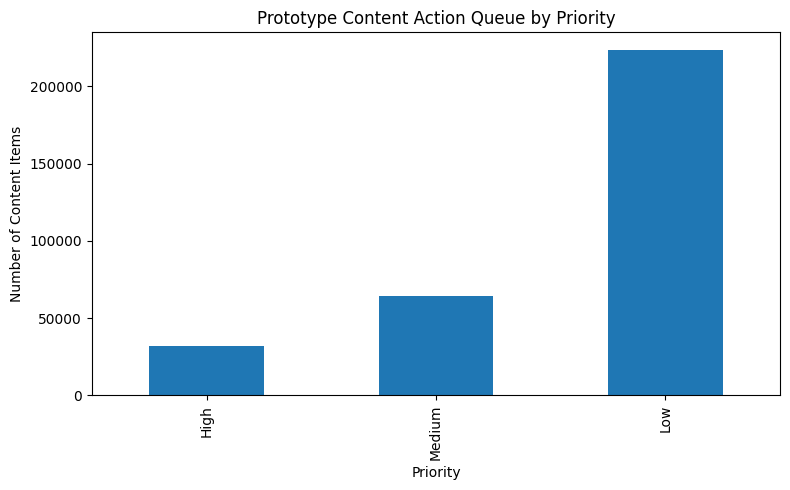

Figure saved to: work/figures/action_queue_priority_distribution.png


In [45]:
import matplotlib.pyplot as plt

priority_counts = (
    action_queue["priority"]
    .value_counts()
    .reindex(["High", "Medium", "Low"])
)

plt.figure(figsize=(8, 5))

priority_counts.plot(kind="bar")

plt.title("Prototype Content Action Queue by Priority")
plt.xlabel("Priority")
plt.ylabel("Number of Content Items")

plt.tight_layout()

figure_path = "work/figures/action_queue_priority_distribution.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to: {figure_path}")

## Self-check

Before you submit, confirm each line honestly:

- [ YES ] Every section above is filled — markdown thinking AND the code that backs it
- [ YES ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ YES ] No client names, URLs, or private queries anywhere
- [ YES ] My claims use careful words: observed, measured, directional, decision-support
- [ YES ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.